## SyriaTel Customer Churn Prediction
### A Machine Learning Approach to Predicting Customer Churn Based on Usage Behavior and Service Interactions

### Problem Statement

SyriaTel, a telecommunications company, is experiencing customer churn; the loss of subscribers who discontinue their service. 
This project aims in building a binary classification model that predicts whether a customer will churn (stop doing business with SyriaTel) based on their usage behavior, account details, plan subscriptions, and service interaction history.
This project helps us to answer the question; *Are there predictable patterns in customer behavior and account characteristics that indicate churn?*

### Stakeholders
- Eecutive Management
- Customer Service Department
- Marketing Team
- Sales Team
- Business Intelligence Analysts


In [148]:
# Import Libraries
# Core
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score

# Models
from sklearn.dummy import DummyClassifier                         
from sklearn.linear_model import LogisticRegression               
from sklearn.tree import DecisionTreeClassifier                   
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier  

# Evaluation
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

# Pipeline
from sklearn.pipeline import Pipeline

## 1. Business Understanding

### Project Overview
This project addresses that need by applying supervised machine learning to SyriaTel's historical customer data.  The target variable is churn — whether a customer left (True) or stayed (False).
The model learns patterns from past churners to score current customers by risk level, giving the retention team a prioritized list of who needs attention before it's too late.

### Stakeholder Analysis

## 2. Data Acqusation and Preparation

### Data Source

The dataset used in this project contains historical customer data from SyriaTel, including usage patterns, service plans, and customer interactions.

## Dataset Overview

- Number of rows: 3,333 customers
- Number of columns: 21 features

The dataset includes both categorical and numerical features.

## Feature Relevance

Key features include:

- Customer service calls → indicates dissatisfaction
- International plan → may affect pricing sensitivity
- Total day minutes → usage behavior
- Voice mail plan → service engagement

These features are relevant because they reflect customer behavior and satisfaction.


#### Step 1. Load Dataset

In [112]:
# Load the SyriaTel churn dataset 
df = pd.read_csv("..\\Data\\bigml_syriatel.csv")  


df.head(10)


,state,account length,area code,phone number,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,...,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,...,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,...,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,...,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,...,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,...,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False
5,AL,118,510,391-8027,yes,no,0,223.4,98,37.98,...,101,18.75,203.9,118,9.18,6.3,6,1.70,0,False
6,MA,121,510,355-9993,no,yes,24,218.2,88,37.09,...,108,29.62,212.6,118,9.57,7.5,7,2.03,3,False
7,MO,147,415,329-9001,yes,no,0,157.0,79,26.69,...,94,8.76,211.8,96,9.53,7.1,6,1.92,0,False
8,LA,117,408,335-4719,no,no,0,184.5,97,31.37,...,80,29.89,215.8,90,9.71,8.7,4,2.35,1,False
9,WV,141,415,330-8173,yes,yes,37,258.6,84,43.96,...,111,18.87,326.4,97,14.69,11.2,5,3.02,0,False


#### Step 2. Data Inspection

In [113]:
# Check number of rows, columns, data types, and missing values
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   state                   3333 non-null   object 
 1   account length          3333 non-null   int64  
 2   area code               3333 non-null   int64  
 3   phone number            3333 non-null   object 
 4   international plan      3333 non-null   object 
 5   voice mail plan         3333 non-null   object 
 6   number vmail messages   3333 non-null   int64  
 7   total day minutes       3333 non-null   float64
 8   total day calls         3333 non-null   int64  
 9   total day charge        3333 non-null   float64
 10  total eve minutes       3333 non-null   float64
 11  total eve calls         3333 non-null   int64  
 12  total eve charge        3333 non-null   float64
 13  total night minutes     3333 non-null   float64
 14  total night calls       3333 non-null   

,account length,area code,number vmail messages,total day minutes,total day calls,total day charge,total eve minutes,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls
count,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000
mean,101.064806,437.182418,8.099010,179.775098,100.435644,30.562307,200.980348,100.114311,17.083540,200.872037,100.107711,9.039325,10.237294,4.479448,2.764581,1.562856
std,39.822106,42.371290,13.688365,54.467389,20.069084,9.259435,50.713844,19.922625,4.310668,50.573847,19.568609,2.275873,2.791840,2.461214,0.753773,1.315491
min,1.000000,408.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,23.200000,33.000000,1.040000,0.000000,0.000000,0.000000,0.000000
25%,74.000000,408.000000,0.000000,143.700000,87.000000,24.430000,166.600000,87.000000,14.160000,167.000000,87.000000,7.520000,8.500000,3.000000,2.300000,1.000000
50%,101.000000,415.000000,0.000000,179.400000,101.000000,30.500000,201.400000,100.000000,17.120000,201.200000,100.000000,9.050000,10.300000,4.000000,2.780000,1.000000
75%,127.000000,510.000000,20.000000,216.400000,114.000000,36.790000,235.300000,114.000000,20.000000,235.300000,113.000000,10.590000,12.100000,6.000000,3.270000,2.000000
max,243.000000,510.000000,51.000000,350.800000,165.000000,59.640000,363.700000,170.000000,30.910000,395.000000,175.000000,17.770000,20.000000,20.000000,5.400000,9.000000


#### Step 3. Simple Data Cleaning

In [114]:
# Drop irrelevant columns
df = df.drop(columns=["state", "phone number"])

# Convert target variable to numeric
df["churn"] = df["churn"].astype(int)

## 3. Handling Categorical Varibales

##### Step 1. One-Hot Encoding

In [115]:
# Convert categorical features into numerical variables
df = pd.get_dummies(
    df,
    columns=["international plan", "voice mail plan"],
    drop_first=True
)

##### Step 2. Feature Engineering

In [116]:
# Total usage
df["total_minutes"] = (
    df["total day minutes"] +
    df["total eve minutes"] +
    df["total night minutes"]
)

# Total charges
df["total_charge"] = (
    df["total day charge"] +
    df["total eve charge"] +
    df["total night charge"]
)

# Service call intensity
df["calls_per_minute"] = df["customer service calls"] / (df["total day minutes"] + 1)

# High complaint flag
df["many_service_calls"] = (df["customer service calls"] > 3).astype(int)

## 4. Exploratory Data Analysis

##### 1. Target Variable Distribution

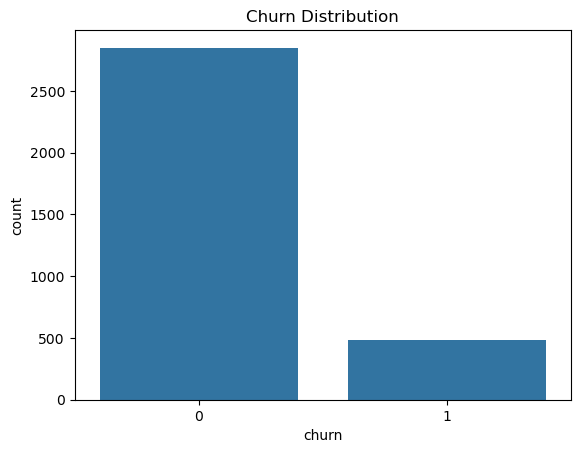

In [117]:
# Check proportion of churners vs non-churners
df["churn"].value_counts(normalize=True)

# Visualize churn distribution
sns.countplot(x="churn", data=df)
plt.title("Churn Distribution")
plt.show()

### Findings

The dataset is highly imbalanced, with significantly more non-churn customers than churn customers. 
This suggests that accuracy alone may not be a reliable metric, and recall or F1-score should be prioritized.

##### 2. Correlation Heatmap

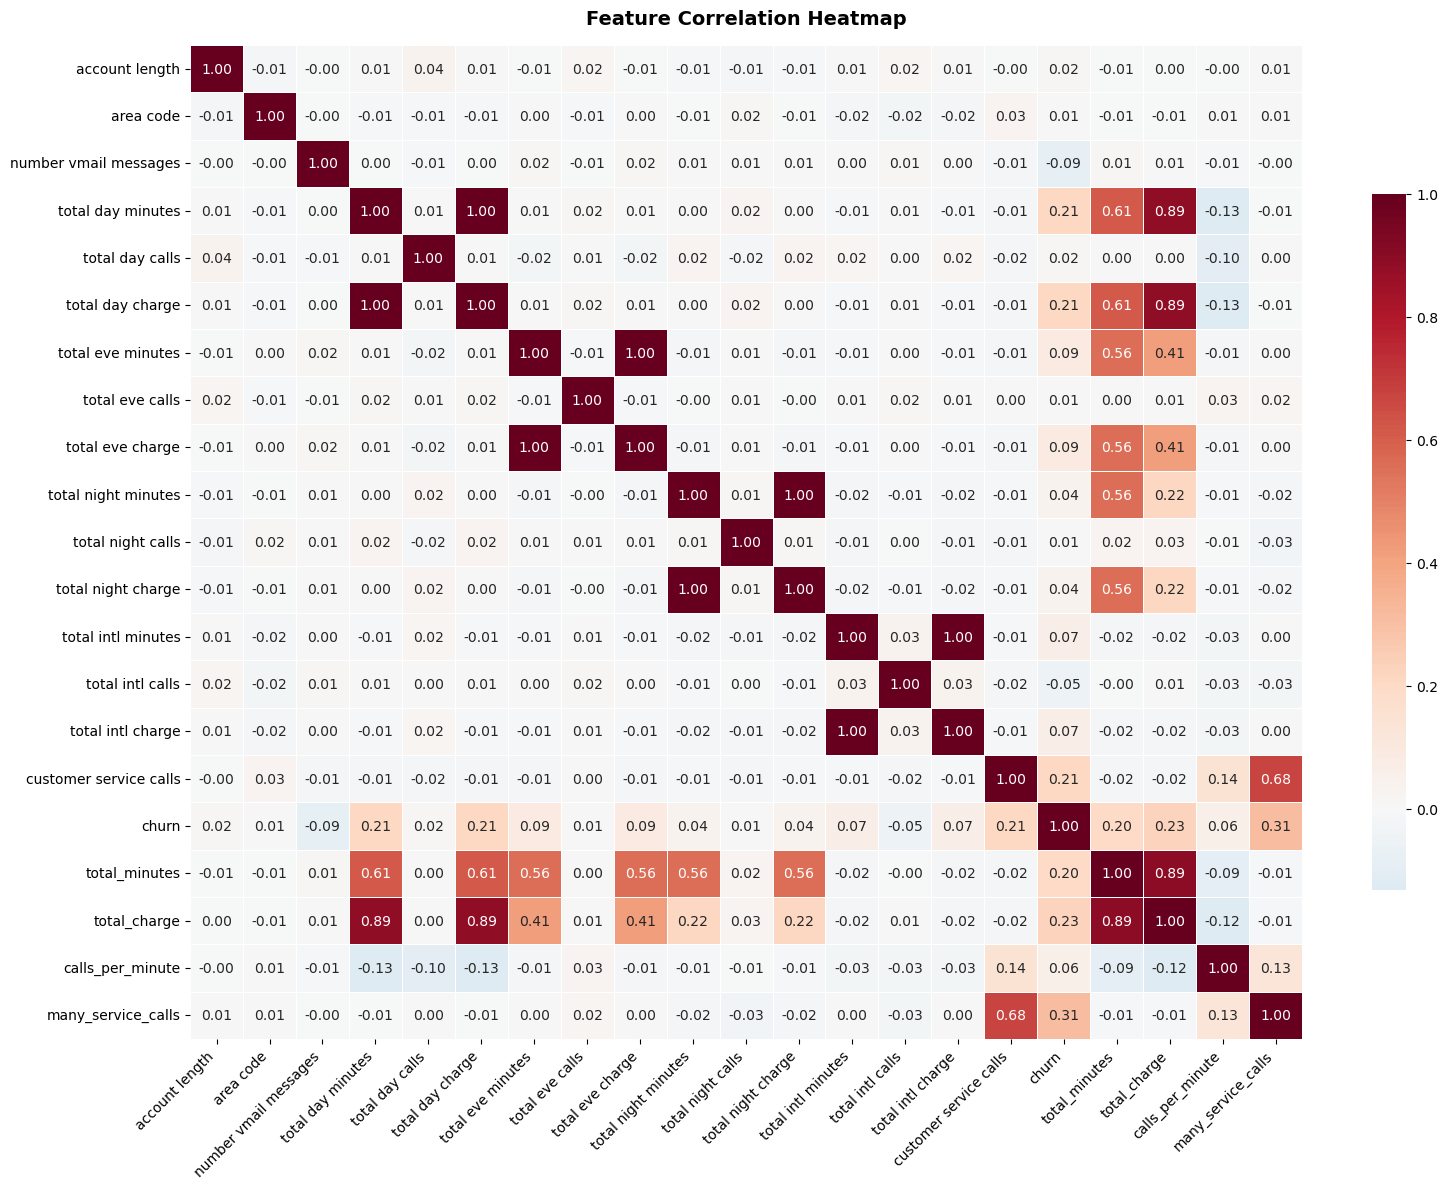

In [118]:
numeric_df = df.select_dtypes(include=['float64', 'int64', 'uint8'])

plt.figure(figsize=(16, 12))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'shrink': 0.7}
)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Findings

Customer service calls and total day minutes show the strongest positive correlation with churn, 
while features like voicemail usage show a negative relationship. 
This suggests behavior and service interaction are key churn drivers.

##### 3. Relationship Between Key Features and Churn

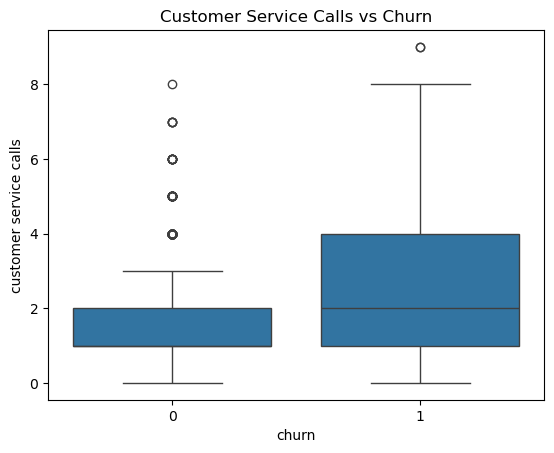

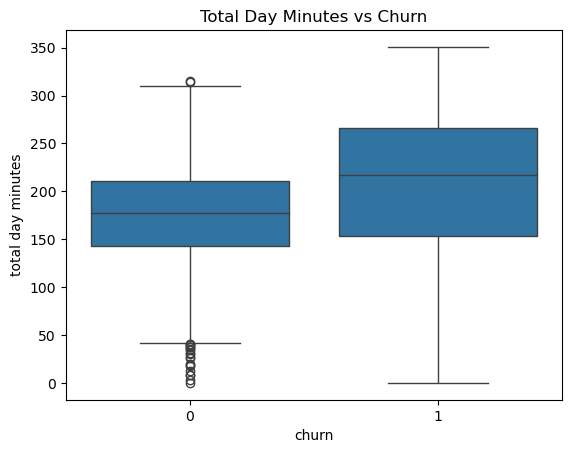

In [119]:
# Compare customer service calls vs churn
sns.boxplot(x="churn", y="customer service calls", data=df)
plt.title("Customer Service Calls vs Churn")
plt.show()

# Compare total day minutes vs churn
sns.boxplot(x="churn", y="total day minutes", data=df)
plt.title("Total Day Minutes vs Churn")
plt.show()

### Findings

Customers who churn tend to make more customer service calls. 
This indicates dissatisfaction is a strong predictor of churn.

##### 4. Distribution of Numerical Features

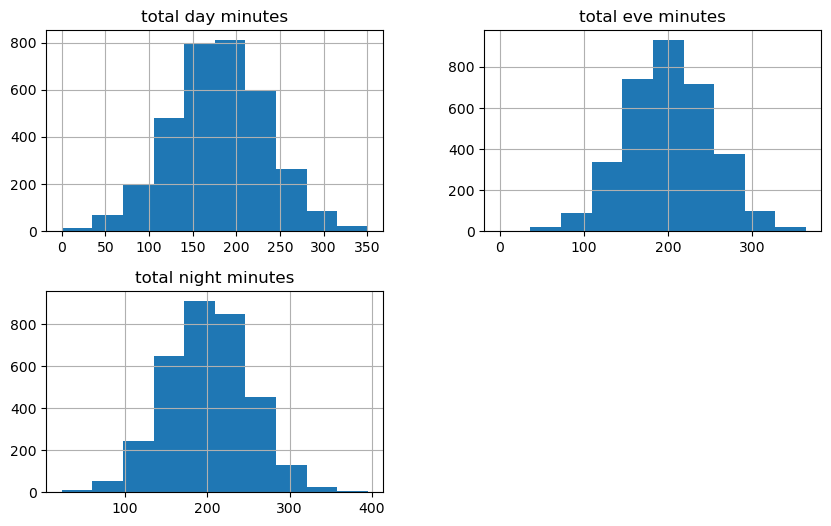

In [120]:
# Plot histogram for key features
df[["total day minutes", "total eve minutes", "total night minutes"]].hist(figsize=(10,6))
plt.show()

### Findings

Customers with higher daytime usage are more likely to churn, 
possibly due to higher billing costs or better competitor offers.

## 5. Train-Test Split

In [ ]:
# Separate features (x) and target (y) variable
X = df.drop("churn", axis=1)
y = df["churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

The dataset is split into training and testing sets to evaluate model performance on unseen data while preserving the class distribution.

### 6. Transform Data

##### Using Scaling Technique

In [ ]:
# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and test sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Feature scaling standardizes numerical values to improve model performance. The scaler is fitted only on training data to prevent data leakage.

## 7. Modelling 

### 1. Baseline Model

##### Dummy Classifier

In [ ]:
dummy = DummyClassifier(strategy='most_frequent', random_state=42)
# Train the model
dummy.fit(X_train, y_train)
# Predict on the test set
y_pred_dummy = dummy.predict(X_test)

print("=== Baseline Model (Dummy Classifier) ===")
print(confusion_matrix(y_test, y_pred_dummy))
print(classification_report(y_test, y_pred_dummy))
print(f"Recall:   {recall_score(y_test, y_pred_dummy):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_dummy):.4f}")

=== Baseline Model (Dummy Classifier) ===
              precision    recall  f1-score   support

           0       0.85      1.00      0.92       570
           1       0.00      0.00      0.00        97

    accuracy                           0.85       667
   macro avg       0.43      0.50      0.46       667
weighted avg       0.73      0.85      0.79       667

Recall:   0.0000
F1-Score: 0.0000


This model always predicts “no churn”
It sets the minimum performance benchmark

The baseline model predicts the majority class (non-churn) and provides a benchmark. 
However, it fails to identify churn cases. Therefore, more complex models such as 
Logistic Regression and Random Forest are introduced to capture patterns in customer behavior.

### 2. Logistic Regression

Logistic Regression is used as a baseline statistical model because it is simple, interpretable, 
and works well for binary classification problems.

### Train Logistic Regression

In [ ]:
# Initialize Logistic Regression with class_weight='balanced' to handle class imbalance
log_model = LogisticRegression(class_weight="balanced", max_iter=1000)

# Train the model on the scaled training data
log_model.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

### Evaluate Logistic Regression

In [ ]:
#Make predictions on the test set
y_pred = log_model.predict(X_test_scaled)

# Evaluate the model
print("Logistic Regression Model")
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

# ROC-AUC
roc_auc_score(y_test, log_model.predict_proba(X_test_scaled)[:,1])

[[482  88]
 [ 14  83]]
              precision    recall  f1-score   support

           0       0.97      0.85      0.90       570
           1       0.49      0.86      0.62        97

    accuracy                           0.85       667
   macro avg       0.73      0.85      0.76       667
weighted avg       0.90      0.85      0.86       667



np.float64(0.8574244890576959)

### 3. Decision Tree Model

In [126]:
dt_model = DecisionTreeClassifier(random_state=42, max_depth=5)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

print("=== Decision Tree ===")
print(classification_report(y_test, y_pred_dt))
print(f"Recall:   {recall_score(y_test, y_pred_dt):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_dt):.4f}")

=== Decision Tree ===
              precision    recall  f1-score   support

           0       0.96      0.99      0.98       570
           1       0.93      0.77      0.84        97

    accuracy                           0.96       667
   macro avg       0.94      0.88      0.91       667
weighted avg       0.96      0.96      0.96       667

Recall:   0.7732
F1-Score: 0.8427


### 4. Random Foreest

Random Forest is introduced to capture nonlinear relationships and interactions between features, improving predictive performance.

### Train Random Forest

In [ ]:
# Initialize Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model on the training data
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

### Evaluate Random Forest 

In [ ]:
# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model
print("Random Forest Model")
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

roc_auc_score(y_test, rf_model.predict_proba(X_test)[:,1])

[[564   6]
 [ 25  72]]
              precision    recall  f1-score   support

           0       0.96      0.99      0.97       570
           1       0.92      0.74      0.82        97

    accuracy                           0.95       667
   macro avg       0.94      0.87      0.90       667
weighted avg       0.95      0.95      0.95       667



np.float64(0.8958762886597939)

### Model Compaison Table

In [ ]:
results = {
    'Model': ['Dummy Classifier', 'Logistic Regression', 'Decision Tree', 'Random Forest (Tuned)'],
    'Recall': [
        recall_score(y_test, y_pred_dummy),
        recall_score(y_test, y_pred),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_final)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_dummy),
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_final)
    ]
}

pd.DataFrame(results).set_index('Model').round(4)

The Random Forest model outperforms both the baseline and Logistic Regression models, 
particularly in recall and F1-score. This indicates that it is better at identifying 
customers who are likely to churn. Therefore, Random Forest is selected for further tuning.

### Hyperparameter Tuning

Hyperparameter tuning is performed to optimize the Random Forest model and improve its ability to generalize.

In [ ]:
# Hyperparameter Tuning for Random Forest
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

# Initialize GridSearch
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='recall',
    n_jobs=-1
)
#Train the model with GridSearch
grid_search.fit(X_train, y_train)

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best CV Recall:  {grid_search.best_score_:.4f}")

# Get the best model from GridSearch after tuning
best_rf = grid_search.best_estimator_


Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Best CV Recall:  0.8342


## Final Model Evaluation

The tuned Random Forest model is evaluated on the test set to assess its real-world performance.

=== FINAL MODEL: Tuned Random Forest (Holdout Test Set) ===

              precision    recall  f1-score   support

           0       0.96      0.99      0.97       570
           1       0.92      0.74      0.82        97

    accuracy                           0.95       667
   macro avg       0.94      0.87      0.90       667
weighted avg       0.95      0.95      0.95       667

Recall:   0.7423
F1-Score: 0.8229
ROC-AUC:  0.8959


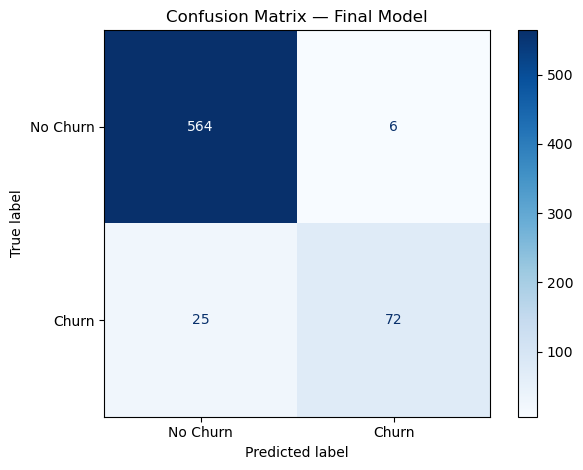

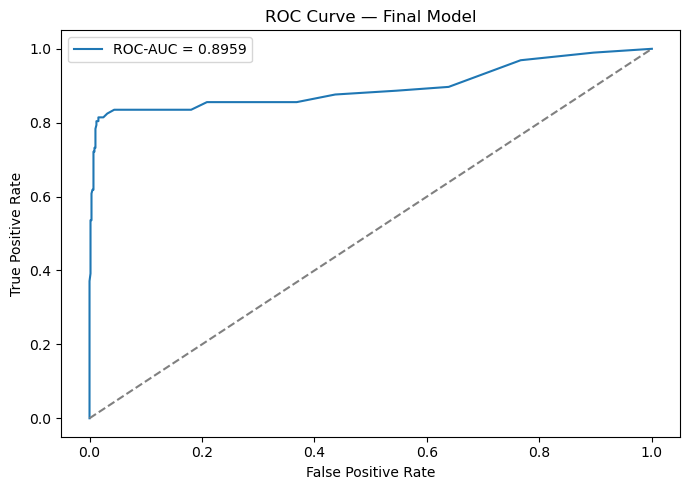

In [131]:
# Final Model Evaluation on Test Set

y_pred_final = best_rf.predict(X_test)
y_proba_final = best_rf.predict_proba(X_test)[:, 1]

print("=== FINAL MODEL: Tuned Random Forest (Holdout Test Set) ===\n")
print(classification_report(y_test, y_pred_final))
print(f"Recall:   {recall_score(y_test, y_pred_final):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_final):.4f}")
print(f"ROC-AUC:  {roc_auc_score(y_test, y_proba_final):.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_final)
ConfusionMatrixDisplay(cm, display_labels=['No Churn', 'Churn']).plot(cmap='Blues')
plt.title('Confusion Matrix — Final Model')
plt.tight_layout()
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba_final)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f'ROC-AUC = {roc_auc_score(y_test, y_proba_final):.4f}')
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Final Model')
plt.legend()
plt.tight_layout()
plt.show()

The Random Forest model is selected as the final model because it achieves higher recall 
for churn prediction, which is critical since failing to identify churn customers has 
greater business consequences.

### ROC-AUC Score

ROC-AUC measures the model’s ability to distinguish between churn and non-churn customers.

In [ ]:
# Calculate ROC-AUC using predicted probabilities
roc_score = roc_auc_score(y_test, best_rf.predict_proba(X_test)[:, 1])

print("ROC-AUC Score:", roc_score)

### Feature Importance

Feature importance identifies which variables contribute most to predicting churn, helping to explain the model’s decisions.

In [149]:
importance = pd.Series(best_rf.feature_importances_, index=X.columns)

# Display top 10 most important features
top_features = importance.sort_values(ascending=False).head(10)
print(top_features)

total_charge              0.193755
total day charge          0.075636
international plan_yes    0.074059
total day minutes         0.070953
total_minutes             0.066121
customer service calls    0.055631
many_service_calls        0.054403
calls_per_minute          0.049029
total intl calls          0.041780
number vmail messages     0.038745
dtype: float64


## Conclusion


The Tuned Random Forest was selected as the final model based on its superior Recall 
and F1-Score on the holdout test set. 

**Key Findings:**
- Customers with 3+ customer service calls are significantly more likely to churn
- High total day minutes and charges correlate strongly with churn
- International plan holders churn at a higher rate

**Business Recommendations:**
- Flag customers with 3+ service calls for immediate retention outreach
- Monitor heavy day-usage customers for pricing dissatisfaction
- Review the international plan offering — consider a loyalty discount

**Limitations:**
- No timestamp data — cannot predict *when* a customer will churn
- Model trained on historical data — requires periodic retraining
- Class imbalance (14.5% churn) addressed with class_weight='balanced'